# Model Optimization and Deployment

Welcome to the third and final notebook of the Machine Learning module. In notebook 1 we cleaned the Titanic data and built preprocessing steps. In notebook 2 we ran an honest model tournament: Logistic Regression won on raw cross-validation score, and the **Random Forest** finished close behind with the most room to improve - it has many more settings we can tune. Today we finish the job: we squeeze more performance out of the Random Forest by tuning those settings, and then we do the thing most courses skip - we put the model **in production**, meaning we turn it into a real web app that anyone on the internet can use.

**What you will learn**

- The difference between parameters and hyperparameters
- How to tune a model with grid search (`GridSearchCV`) and random search (`RandomizedSearchCV`)
- Why the test set may only be used once, at the very end
- What "production" actually means in plain words
- How to save a trained model to a file and load it back (`joblib`)
- How to wrap a model in a small web app with Gradio
- How to deploy that app for free on Hugging Face Spaces, using only your browser

## How to run this notebook

- **Locally (Jupyter):** open this file in Jupyter and run the cells top to bottom.
- **Google Colab:** upload this file to [colab.research.google.com](https://colab.research.google.com) (or open it straight from GitHub) and run the cells top to bottom.

The setup cell below installs any missing packages automatically, so both options work out of the box. Running everything requires **no accounts of any kind**. Only the *optional* final step - publishing your app on the internet - needs a free Hugging Face account.

This notebook is **self-contained**: it repeats the data preparation from notebook 1 in one compact cell, so you can run it on its own.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("sklearn", "scikit-learn"); ensure("matplotlib"); ensure("joblib"); ensure("gradio")

## 1. Where we are

A quick recap of the journey so far:

- **Notebook 1** - we explored the Titanic passenger data, invented helpful new columns (like `Title` and `FamilySize`), and built a preprocessing pipeline that fills gaps and converts text to numbers.
- **Notebook 2** - we tried several models with cross-validation. Logistic Regression scored best out of the box, but the **Random Forest** finished within a whisker of it - and unlike Logistic Regression, it has many knobs left to turn. Notebook 2 handed it to us as the tuning candidate, and we take it as our given starting point today.
- **This notebook** - we tune the Random Forest (we will keep calling it our champion), then ship it as a real app.

### Parameters vs hyperparameters

Two words that sound alike but mean very different things:

- A **parameter** is a value the model *learns from the data* during training. In a Random Forest, the split rules inside each tree are parameters. You never set them by hand.
- A **hyperparameter** is a setting *you choose before training starts*. For a Random Forest: how many trees to grow, how deep each tree may go, and so on.

A kitchen analogy: when you bake a cake, the **oven temperature** is a hyperparameter - you set the knob before baking. How the ingredients actually absorb the heat and turn into cake is like the parameters - that happens on its own, inside, during the process. Tuning a model means trying different knob positions and keeping the one that produces the best cake.

## 2. Rebuild the data and the champion pipeline

The cell below repeats the data preparation from notebook 1 in compact form (see notebook 1, `01-data-prep-and-feature-engineering`, for the full explanation of every step). In short:

- Download the Titanic passenger list.
- Create `Title` (Mr/Mrs/Miss/Master/Rare, pulled out of the `Name` column), `FamilySize` (siblings + parents/children + the passenger), and `IsAlone`.
- List which columns are numeric and which are categorical (categories, like `Sex`).
- Build a **ColumnTransformer**: a scikit-learn object that applies different cleaning steps to different columns. Numeric columns get missing values filled with the median and are scaled; categorical columns get missing values filled with the most frequent value and are one-hot encoded (turned into 0/1 columns).
- Split the data into a training set (80%) and a test set (20%) that we lock away until the very end.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1) Load the data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2) Feature engineering (same as notebook 1)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
common_titles = ["Mr", "Mrs", "Miss", "Master"]
df.loc[~df["Title"].isin(common_titles), "Title"] = "Rare"
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# 3) Choose the columns the model will use
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title"]

X = df[numeric_features + categorical_features]
y = df["Survived"]

# 4) Preprocessing: different treatment for numeric vs categorical columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# 5) Train/test split - the test set stays locked away until section 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

Training rows: 712
Test rows:     179


### The baseline: how good is our model *before* tuning?

We rebuild the pipeline exactly as notebook 2 left it: preprocessing plus a Random Forest with default settings. Then we measure it with **cross-validation** (splitting the training data into 5 folds and taking the average score - the same technique from notebook 2).

Why measure first? Because tuning only counts as an improvement if we know the starting score. This baseline is our "before" photo.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# The champion pipeline from notebook 2: preprocessing + Random Forest, default settings
champion = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

baseline_score = cross_val_score(champion, X_train, y_train, cv=5, n_jobs=-1).mean()
print(f"Baseline cross-validation accuracy (default settings): {baseline_score:.4f}")

Baseline cross-validation accuracy (default settings): 0.7937


## 3. Grid search: trying every combination

### The idea

A Random Forest has several knobs. Which combination of knob positions is best? The most honest answer: **try them all and measure**. That strategy is called **grid search** - you write down a "grid" of candidate values for each knob, and try every possible combination.

There is no magic in it. `GridSearchCV` is literally cross-validation plus a for-loop over settings. If you wrote it yourself, it would look like this pseudocode:

```text
best_score = 0
for n_estimators in [100, 300]:
    for max_depth in [4, 8, None]:
        for min_samples_leaf in [1, 3, 5]:
            score = average cross-validation score with these settings
            if score > best_score:
                best_score = score
                remember these settings
```

That is 2 x 3 x 3 = 18 combinations, each measured with 5-fold cross-validation, so 90 model trainings in total. `GridSearchCV` does exactly this, but in one line and using all your CPU cores.

### The knobs we will tune

- `n_estimators` - how many trees in the forest. More trees is usually a bit better but slower.
- `max_depth` - how deep each tree may grow. `None` means "no limit". Deep trees can memorize noise (overfitting); shallow trees may be too simple.
- `min_samples_leaf` - the minimum number of passengers that must end up in a leaf (an end point of a tree). Larger values make the trees smoother and less likely to memorize individuals.

One naming detail: our model lives *inside* a pipeline under the name `"model"`, so the knob names get a prefix: `model__n_estimators` (two underscores). That is how scikit-learn knows which step of the pipeline the setting belongs to.

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [4, 8, None],
    "model__min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(
    champion,          # the full pipeline: preprocessing + model
    param_grid,        # the grid of settings to try
    cv=5,              # 5-fold cross-validation for every combination
    n_jobs=-1,         # use all CPU cores
)
grid_search.fit(X_train, y_train)

print("Best settings found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Baseline was:                   {baseline_score:.4f}")
print(f"Improvement:                    {grid_search.best_score_ - baseline_score:+.4f}")

Best settings found: {'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best cross-validation accuracy: 0.8259
Baseline was:                   0.7937
Improvement:                    +0.0322


### Looking at all the results, not just the winner

`GridSearchCV` keeps the score of *every* combination in `cv_results_`. Looking at the whole picture teaches you more than the single winner: you see which knobs matter and which barely move the needle.

Below we show the top 5 combinations as a table, and a **heatmap** (a grid of colored squares, brighter = better score) of `max_depth` vs `min_samples_leaf`, averaged over the two `n_estimators` values.

,n_estimators,max_depth,min_samples_leaf,mean_cv_accuracy,std
0,100,4,5,0.8259,0.0138
1,100,None,3,0.8245,0.0212
2,100,4,3,0.8245,0.0143
3,300,8,3,0.8231,0.0209
4,300,4,1,0.8231,0.0174


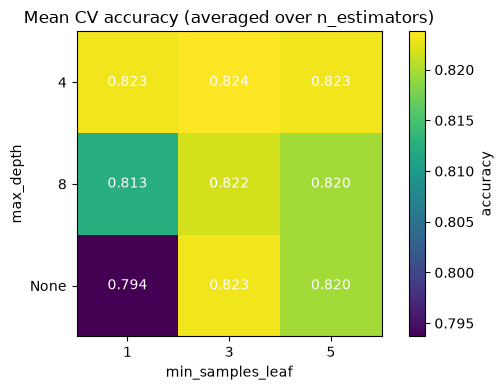

In [5]:
import matplotlib.pyplot as plt

results = pd.DataFrame(grid_search.cv_results_)

# --- Top 5 combinations as a table ---
nice_cols = {
    "param_model__n_estimators": "n_estimators",
    "param_model__max_depth": "max_depth",
    "param_model__min_samples_leaf": "min_samples_leaf",
    "mean_test_score": "mean_cv_accuracy",
    "std_test_score": "std",
}
top5 = (
    results[list(nice_cols)]
    .rename(columns=nice_cols)
    .sort_values("mean_cv_accuracy", ascending=False)
    .head(5)
    .round(4)
    .reset_index(drop=True)
)
display(top5)

# --- Heatmap: max_depth vs min_samples_leaf ---
# Turn the depth values (4, 8, None) into text labels for the plot axis
def depth_label(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "None"
    return str(int(v))

results["max_depth_str"] = [depth_label(v) for v in results["param_model__max_depth"]]
pivot = results.pivot_table(
    index="max_depth_str",
    columns="param_model__min_samples_leaf",
    values="mean_test_score",
    aggfunc="mean",
).reindex(["4", "8", "None"])

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="viridis")
ax.set_xticks(range(pivot.shape[1]), labels=pivot.columns.tolist())
ax.set_yticks(range(pivot.shape[0]), labels=pivot.index.tolist())
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.set_title("Mean CV accuracy (averaged over n_estimators)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="accuracy")
plt.tight_layout()
plt.show()

## 4. Random search: trying random combinations

Grid search has a weakness: it explodes. Tune 5 knobs with 6 values each and you get 6^5 = 7,776 combinations - times 5 folds, that is almost 39,000 trainings. Nobody has time for that.

**Random search** takes a different bet: instead of trying every combination, draw a fixed number of *random* combinations from (possibly much wider) ranges. This often wins in practice, for a simple reason: with a grid, 15 tries might only test 2 or 3 distinct values per knob. With random draws, those same 15 tries test up to 15 *different* values of every knob at once. If only one or two knobs really matter (which is typical), random search explores them far more thoroughly for the same budget.

`RandomizedSearchCV` works exactly like `GridSearchCV`, but you give it ranges/distributions instead of fixed lists, plus `n_iter` (how many random combinations to try). Note `random_state=42`: the "random" draws are reproducible.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Wider ranges than the grid - random search can afford to explore more
param_distributions = {
    "model__n_estimators": randint(100, 401),        # any integer from 100 to 400
    "model__max_depth": [3, 4, 5, 6, 8, 10, 12, None],
    "model__min_samples_leaf": randint(1, 10),       # any integer from 1 to 9
    "model__max_features": ["sqrt", "log2", None],   # how many columns each split may look at
}

random_search = RandomizedSearchCV(
    champion,
    param_distributions,
    n_iter=15,          # try 15 random combinations
    cv=5,
    n_jobs=-1,
    random_state=42,
)
random_search.fit(X_train, y_train)

print("Best settings found:", random_search.best_params_)
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

Best settings found: {'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 314}
Best cross-validation accuracy: 0.8274


### Grid vs random: the scoreboard

Let's put the two searches side by side, together with the untuned baseline.

In [7]:
comparison = pd.DataFrame({
    "method": ["No tuning (baseline)", "Grid search (18 combos)", "Random search (15 combos)"],
    "best_cv_accuracy": [
        round(baseline_score, 4),
        round(grid_search.best_score_, 4),
        round(random_search.best_score_, 4),
    ],
})
display(comparison)

# Keep whichever search found the better model - already refit on ALL training data
if grid_search.best_score_ >= random_search.best_score_:
    best_search, best_search_name = grid_search, "grid search"
else:
    best_search, best_search_name = random_search, "random search"
best_model = best_search.best_estimator_
print(f"Winner: {best_search_name} with CV accuracy {best_search.best_score_:.4f}")

,method,best_cv_accuracy
0,No tuning (baseline),0.7937
1,Grid search (18 combos),0.8259
2,Random search (15 combos),0.8274


Winner: random search with CV accuracy 0.8274


Do not be surprised if the gains look small - on a small, well-studied dataset like Titanic, default settings are already decent. Tuning usually buys you a percentage point or two, not miracles. On larger, messier problems the gains are often bigger. Either way, you now know the honest way to look for them.

One convenience worth knowing: after the search finishes, `GridSearchCV` and `RandomizedSearchCV` automatically **refit** the best combination on the *entire* training set. That refit model is stored in `best_estimator_` - it is ready to use, no extra training needed.

## 5. The honest final exam: one look at the test set

> **Warning - read this twice.** The test set is used **exactly once, at the very end**. If you peek at test scores while tuning and go back to change settings, the test set silently becomes training data: your "final" score is no longer an honest estimate of how the model handles unseen passengers. That is why all tuning above used cross-validation *inside the training set only*.

We now take our best model and evaluate it one single time on the 179 passengers it has never seen. We report:

- **Accuracy** - the share of passengers predicted correctly.
- **F1 score** - a balance of precision (when we predict "survived", how often is that right?) and recall (of the real survivors, how many did we find?). Useful when the two classes are not 50/50.
- **Confusion matrix** - a 2x2 table showing exactly where the model was right and where it was wrong.

Test accuracy: 0.8268
Test F1 score: 0.7597


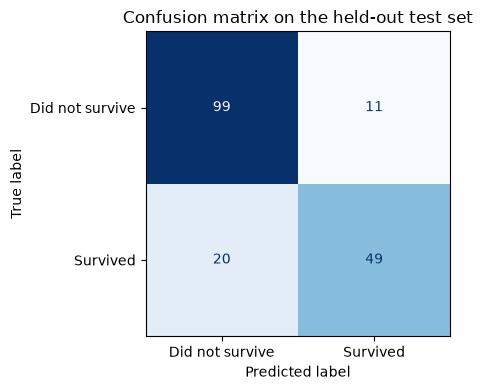

In [8]:
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1 score: {f1_score(y_test, y_pred):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion matrix on the held-out test set")
plt.tight_layout()
plt.show()

How to read the matrix: rows are the truth, columns are the prediction. The top-left and bottom-right squares are correct predictions; the other two squares are the mistakes. If the test accuracy is close to the cross-validation accuracy, that is good news: the model generalizes, and our tuning process did not fool itself.

The model is done. Time to ship it.

## 6. What "production" actually means

A model that only lives in your notebook helps nobody. Your classmate cannot use it, a website cannot call it, and it dies when you close the tab.

**Production** simply means: *the model runs somewhere real users (or other programs) can reach it.* That "somewhere" can be:

- a **web app** with buttons and sliders (what we build today),
- an **API** - a web address that other programs send data to and get predictions back,
- a **scheduled job** - for example, a script that scores all new customers every night.

The minimal production loop is always the same five steps:

1. **Save** the trained model to a file.
2. **Load** it in another program.
3. **Wrap** it in an interface (a web page or an API).
4. **Host** it on a machine that is always on.
5. **Monitor** it while it runs.

Two words about step 5, because beginners always skip it. First, **data drift**: the world changes; yesterday's model slowly goes stale. A model trained on 2024 customers may misjudge 2026 customers, so real systems track the model's live accuracy and the shape of incoming data, and retrain when things slip. Second, **versioning**: name every saved model with a version or date (`model_v1`, `model_2026_09_06`), so you always know which model is running and can roll back if a new one misbehaves.

## 7. Saving and loading the model

We save with **joblib**, a library that writes Python objects to disk efficiently (`.joblib` files).

The single most important habit here: **save the ENTIRE pipeline, not just the model**. Our pipeline contains the preprocessing (imputers, scaler, one-hot encoder) *and* the Random Forest. The app that serves predictions must clean incoming data *exactly* the way the training data was cleaned - same median values for filling gaps, same scaling, same category columns. If you save only the forest, you would have to rebuild all of that by hand in the app, and any tiny difference silently produces wrong predictions. Saving the pipeline makes this a non-issue: raw passenger data in, prediction out.

Note the file name: `titanic_model_v1.joblib` - versioned, as promised in section 6.

In [9]:
import os
import joblib

os.makedirs("outputs", exist_ok=True)
model_path = os.path.join("outputs", "titanic_model_v1.joblib")

# Save the WHOLE pipeline: preprocessing + tuned Random Forest
joblib.dump(best_model, model_path)
size_kb = os.path.getsize(model_path) / 1024
print(f"Saved: {model_path} ({size_kb:.0f} KB)")

# Load it back into a FRESH variable, as a separate app would do
loaded_model = joblib.load(model_path)
print("Loaded back:", type(loaded_model).__name__)

Saved: outputs/titanic_model_v1.joblib (2599 KB)
Loaded back: Pipeline


### Sanity check: predict for two invented passengers

`loaded_model` is now a completely independent copy, exactly like the one a web app would load. Let's ask it about two made-up passengers:

- a 30-year-old **first-class woman** who boarded in Cherbourg,
- a 28-year-old **third-class man** who boarded in Southampton.

We use two methods:

- `predict` returns the final answer: 1 (survived) or 0 (did not survive).
- `predict_proba` returns the **probability** of each class - much more informative than a bare yes/no.

In [10]:
new_passengers = pd.DataFrame([
    {"Pclass": 1, "Sex": "female", "Age": 30.0, "SibSp": 0, "Parch": 0,
     "Fare": 80.0, "Embarked": "C", "Title": "Mrs", "FamilySize": 1, "IsAlone": 1},
    {"Pclass": 3, "Sex": "male", "Age": 28.0, "SibSp": 0, "Parch": 0,
     "Fare": 7.9, "Embarked": "S", "Title": "Mr", "FamilySize": 1, "IsAlone": 1},
])

predictions = loaded_model.predict(new_passengers)
probabilities = loaded_model.predict_proba(new_passengers)

# Which column of predict_proba is "survived" (class 1)?
survived_col = list(loaded_model.classes_).index(1)

labels = ["First-class woman, 30", "Third-class man, 28"]
for name, pred, proba in zip(labels, predictions, probabilities):
    p = proba[survived_col]
    verdict = "SURVIVES" if pred == 1 else "does NOT survive"
    print(f"{name}: predicted {verdict} (survival probability {p:.0%})")

First-class woman, 30: predicted SURVIVES (survival probability 100%)


Third-class man, 28: predicted does NOT survive (survival probability 3%)


How to read this: a survival probability of, say, 95% means "out of 100 very similar passengers, the model expects about 95 to survive". It is a statement of confidence, not a guarantee about one individual. The gap between the two passengers reflects the sad reality of the Titanic that we saw in notebook 1: class and sex were the strongest factors in who got a lifeboat seat.

## 8. Wrapping the model in an app with Gradio

**Gradio** is a Python library that turns any function into a web app. You write a normal function, tell Gradio what the inputs and outputs look like, and it generates a web page with sliders, dropdowns and a button - no HTML or JavaScript needed.

Our function takes the details a user can reasonably type in (class, sex, age, family aboard, fare, port), builds a one-row DataFrame with all the columns the pipeline expects, and returns a friendly sentence. Two features from notebook 1 are not asked from the user - we derive them:

- `Title`: a simple rule from sex and age (boys under 13 get "Master", men "Mr"; girls under 18 "Miss", women "Mrs").
- `FamilySize` and `IsAlone`: computed from the family counts.

In [11]:
import os
os.environ["GRADIO_ANALYTICS_ENABLED"] = "False"  # do not send usage statistics
import gradio as gr

def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    """Return a friendly survival prediction for one passenger."""
    family_size = sibsp + parch + 1
    if sex == "male":
        title = "Master" if age < 13 else "Mr"
    else:
        title = "Miss" if age < 18 else "Mrs"
    row = pd.DataFrame([{
        "Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
        "Parch": parch, "Fare": fare, "Embarked": embarked,
        "Title": title, "FamilySize": family_size,
        "IsAlone": 1 if family_size == 1 else 0,
    }])
    p = loaded_model.predict_proba(row)[0][survived_col]
    verdict = "likely to SURVIVE" if p >= 0.5 else "NOT likely to survive"
    return f"Survival probability: {p:.0%}. This passenger is {verdict}."

# Quick test - it is just a normal Python function
print(predict_survival(1, "female", 30, 0, 0, 80.0, "C"))
print(predict_survival(3, "male", 28, 0, 0, 7.9, "S"))

Survival probability: 100%. This passenger is likely to SURVIVE.
Survival probability: 3%. This passenger is NOT likely to survive.


The function works. Now we describe the user interface: one Gradio input component per function argument (in the same order), and a textbox for the output. Building the interface object does not start anything yet - it is just a description of the app.

In [12]:
demo = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Dropdown([1, 2, 3], value=3, label="Passenger class (1 = first class)"),
        gr.Radio(["male", "female"], value="female", label="Sex"),
        gr.Slider(0, 80, value=30, step=1, label="Age"),
        gr.Slider(0, 8, value=0, step=1, label="Siblings / spouses aboard"),
        gr.Slider(0, 6, value=0, step=1, label="Parents / children aboard"),
        gr.Slider(0, 300, value=32, step=1, label="Ticket fare (pounds)"),
        gr.Dropdown(["S", "C", "Q"], value="S",
                    label="Port of embarkation (S = Southampton, C = Cherbourg, Q = Queenstown)"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Titanic Survival Predictor",
    description="Enter passenger details and the model estimates the chance of survival.",
)
print("Interface built. Set LAUNCH_DEMO = True in the next cell to open it.")

Interface built. Set LAUNCH_DEMO = True in the next cell to open it.


### Launching the app

`demo.launch()` starts a small web server and shows the app right below the cell. We keep it behind a switch so the notebook can also run unattended from top to bottom (a running server would block execution).

Nice extra: on **Google Colab**, `launch()` also prints a temporary public link (something like `https://....gradio.live`) that stays alive for a few hours - you can send it to a friend and they can use your model from their phone. For a *permanent* link, continue to section 9.

In [13]:
LAUNCH_DEMO = False  # set to True to open the app right here in the notebook
if LAUNCH_DEMO:
    demo.launch()

## 9. Deploying for real: Hugging Face Spaces

**Hugging Face Spaces** is a free hosting service for small machine-learning apps: you upload a few files in the browser and it gives your app a permanent public web address. The free tier (basic CPU) is more than enough for our model, and it needs no credit card.

A Space running Gradio needs exactly four files:

1. `app.py` - a standalone version of our Gradio app that loads the model file from its own folder,
2. `titanic_model_v1.joblib` - the saved pipeline,
3. `requirements.txt` - the packages the Space must install,
4. `README.md` - with a special header that tells Hugging Face how to run the app.

The next cell **writes all four files** into `outputs/deployment/`, ready to upload.

> **Security note, once and for all:** the upload flow below happens entirely in the **web browser** - no command line, no access tokens. Never paste passwords, API keys, or tokens into a notebook or a code file, and never commit them to git. Anything you commit is very hard to truly delete.

In [14]:
import shutil
import sklearn
import gradio

deploy_dir = os.path.join("outputs", "deployment")
os.makedirs(deploy_dir, exist_ok=True)

# ---- 1) app.py: a standalone version of the Gradio app ----
APP_PY = '''\
# Titanic Survival Predictor - Gradio app for Hugging Face Spaces.
# Loads the trained pipeline (preprocessing + model) from its own folder.
from pathlib import Path

import joblib
import pandas as pd
import gradio as gr

MODEL_PATH = Path(__file__).parent / "titanic_model_v1.joblib"
model = joblib.load(MODEL_PATH)
SURVIVED_COL = list(model.classes_).index(1)

def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    family_size = sibsp + parch + 1
    if sex == "male":
        title = "Master" if age < 13 else "Mr"
    else:
        title = "Miss" if age < 18 else "Mrs"
    row = pd.DataFrame([{
        "Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
        "Parch": parch, "Fare": fare, "Embarked": embarked,
        "Title": title, "FamilySize": family_size,
        "IsAlone": 1 if family_size == 1 else 0,
    }])
    p = model.predict_proba(row)[0][SURVIVED_COL]
    verdict = "likely to SURVIVE" if p >= 0.5 else "NOT likely to survive"
    return f"Survival probability: {p:.0%}. This passenger is {verdict}."

demo = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Dropdown([1, 2, 3], value=3, label="Passenger class (1 = first class)"),
        gr.Radio(["male", "female"], value="female", label="Sex"),
        gr.Slider(0, 80, value=30, step=1, label="Age"),
        gr.Slider(0, 8, value=0, step=1, label="Siblings / spouses aboard"),
        gr.Slider(0, 6, value=0, step=1, label="Parents / children aboard"),
        gr.Slider(0, 300, value=32, step=1, label="Ticket fare (pounds)"),
        gr.Dropdown(["S", "C", "Q"], value="S",
                    label="Port of embarkation (S = Southampton, C = Cherbourg, Q = Queenstown)"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Titanic Survival Predictor",
    description="Enter passenger details and the model estimates the chance of survival.",
)

if __name__ == "__main__":
    demo.launch()
'''
with open(os.path.join(deploy_dir, "app.py"), "w") as f:
    f.write(APP_PY)

# ---- 2) requirements.txt ----
# scikit-learn is PINNED to the exact training version: a model saved (pickled)
# with one version may fail to load - or load incorrectly - with another.
REQUIREMENTS = f'''\
gradio
# scikit-learn must match the version the model was trained with,
# otherwise the .joblib file may not load correctly on the Space.
scikit-learn=={sklearn.__version__}
pandas
numpy
joblib
'''
with open(os.path.join(deploy_dir, "requirements.txt"), "w") as f:
    f.write(REQUIREMENTS)

# ---- 3) README.md with the Hugging Face Spaces header (YAML front matter) ----
README = f'''\
---
title: Titanic Survival Predictor
colorFrom: blue
colorTo: gray
sdk: gradio
sdk_version: {gradio.__version__}
app_file: app.py
pinned: false
---

# Titanic Survival Predictor

A small demo app built in the Fontys Machine Learning module.
It uses a tuned Random Forest pipeline to estimate the survival
probability of a Titanic passenger from their details.
'''
with open(os.path.join(deploy_dir, "README.md"), "w") as f:
    f.write(README)

# ---- 4) Copy the saved model next to app.py ----
shutil.copy(model_path, os.path.join(deploy_dir, "titanic_model_v1.joblib"))

print("Deployment folder ready:")
for name in sorted(os.listdir(deploy_dir)):
    full = os.path.join(deploy_dir, name)
    print(f"  {name:28s} {os.path.getsize(full) / 1024:8.1f} KB")

Deployment folder ready:
  README.md                         0.3 KB
  __pycache__                       0.1 KB
  app.py                            1.9 KB
  requirements.txt                  0.2 KB
  titanic_model_v1.joblib        2599.3 KB


### The exact clicks: from folder to live URL

Everything below happens in your web browser - no command line, no tokens.

1. Go to [huggingface.co](https://huggingface.co) and click **Sign Up** (free, only an email address needed).
2. Once logged in, click your profile picture (top right) and choose **New Space**.
3. Fill in the form:
   - **Space name**: for example `titanic-survival-predictor`
   - **License**: `mit` is fine
   - **Select the Space SDK**: choose **Gradio**
   - **Hardware**: keep the free option, **CPU basic**
   - Keep the Space **Public** so friends can visit it
4. Click **Create Space**.
5. Open the **Files** tab of your new Space, click **Add file**, then **Upload files**.
6. Drag and drop the **4 files** from your local `outputs/deployment/` folder: `app.py`, `requirements.txt`, `README.md`, and `titanic_model_v1.joblib`. (Uploading `README.md` will overwrite the auto-generated one - that is exactly what we want.) Click **Commit changes to main**.
7. The Space now builds automatically - watch the status at the top turn from *Building* to *Running* (about 2 minutes).
8. Done. Your model is live at `https://huggingface.co/spaces/YOUR-USERNAME/titanic-survival-predictor` - a public URL anyone in the world can visit.

**If the build fails:** open the **Logs** tab of the Space and read the last lines. The usual cause is a version mismatch in `requirements.txt` - for example, the pinned scikit-learn version not matching the model file, or an `sdk_version` in `README.md` that Spaces does not support (you can simply delete the `sdk_version` line to get the default).

Congratulations - you have a machine learning model **in production**.

## 10. Other ways to deploy (a quick tour)

Gradio on Spaces is perfect for demos with a human at the keyboard. Two other paths you will meet in practice:

**A FastAPI endpoint** - when *other programs* (a website backend, a mobile app) need predictions, you expose the model as an API instead of a page with sliders. FastAPI is the most popular Python library for this. For flavor only - **do not run this here**, it needs a server:

```python
# app_api.py - illustrative only, do not run in this notebook
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("titanic_model_v1.joblib")

@app.post("/predict")
def predict(passenger: dict):
    row = pd.DataFrame([passenger])
    proba = float(model.predict_proba(row)[0][1])
    return {"survival_probability": round(proba, 3)}
```

Ten lines: any program can now POST passenger data to `/predict` and get a probability back as JSON.

**Streamlit Community Cloud** - Streamlit is a Gradio alternative for building data apps in Python; its Community Cloud hosts them for free straight from a GitHub repository.

**"Big company" options** - at enterprise scale, teams use cloud ML platforms that handle serving, scaling, monitoring, and retraining: AWS SageMaker, Google Vertex AI, Azure Machine Learning, Databricks. Names to recognize, not tools you need today.

## Key takeaways

- **Parameters** are learned from data; **hyperparameters** are settings you choose - like the oven temperature vs the cake baking inside.
- Always measure a **baseline before tuning**, or you cannot claim improvement.
- **Grid search** = cross-validation + a for-loop over every combination. Honest but explodes with many knobs.
- **Random search** covers more distinct values per knob for the same budget - often the better deal on big search spaces.
- The **test set is used exactly once**, at the very end. Tune against it and it silently becomes training data.
- **Production** means the model runs somewhere users can reach it. The loop: save -> load -> wrap -> host -> monitor.
- Save the **entire pipeline**, not just the model, so the app cleans data exactly like training did. Version your saved files.
- Models go **stale** (data drift) - real systems monitor live performance and retrain.
- **Gradio** turns a function into a web app; **Hugging Face Spaces** hosts it for free - browser uploads only, and never put tokens or passwords in code.

## Practice exercises

Try these yourself before looking at the solutions.

**Exercise 1 - Tune two more hyperparameters.** Run a small grid search over two Random Forest knobs we did not tune in section 3: `max_features` (try `"sqrt"` and `None`) and `criterion` (try `"gini"` and `"entropy"`), keeping the other settings at the best values found by our grid search. Report the best cross-validation score. Did it beat the section 3 winner?

**Exercise 2 - An "embarked" what-if.** Write a function that takes one passenger's details (without the port) and returns the survival probability for **each of the three ports** (S, C, Q), so a user can see whether the port of embarkation changes the model's mind. Print the result for the third-class man from section 7. (Bonus thought: how would you show this in the Gradio app?)

**Exercise 3 - Save a v2 model.** Take the best model from Exercise 1 (or from the random search, if that one was better), save it as a version-2 file with today's date in the name, and print a short note explaining what changed compared to `titanic_model_v1.joblib`. Why do we keep v1 around?

**Exercise 4 - Spotting a stale model.** In exactly 3 sentences, describe how you would notice that your deployed Titanic app (or any deployed model) is going stale.

## Solutions

### Solution 1 - Tune two more hyperparameters

We fix the knobs from section 3 at their best values (taking them from `grid_search.best_params_`) and search only over the two new ones: 2 x 2 = 4 combinations.

In [15]:
extra_grid = {
    "model__max_features": ["sqrt", None],
    "model__criterion": ["gini", "entropy"],
}

# Start from the section 3 winner: clone its best settings into a fresh pipeline
from sklearn.base import clone
tuned_champion = clone(champion).set_params(**grid_search.best_params_)

extra_search = GridSearchCV(tuned_champion, extra_grid, cv=5, n_jobs=-1)
extra_search.fit(X_train, y_train)

print("Best extra settings:", extra_search.best_params_)
print(f"Best CV accuracy now:      {extra_search.best_score_:.4f}")
print(f"Section 3 grid search was: {grid_search.best_score_:.4f}")
if extra_search.best_score_ > grid_search.best_score_:
    print("Verdict: the two extra knobs helped.")
else:
    print("Verdict: no improvement - the defaults for these knobs were already fine. "
          "That is a perfectly normal (and honest) tuning result.")

Best extra settings: {'model__criterion': 'gini', 'model__max_features': 'sqrt'}
Best CV accuracy now:      0.8259
Section 3 grid search was: 0.8259
Verdict: no improvement - the defaults for these knobs were already fine. That is a perfectly normal (and honest) tuning result.


### Solution 2 - An "embarked" what-if

Same recipe as `predict_survival`, but we loop over the three ports and collect the probabilities in a small table. In the Gradio app, you could show this as a second output textbox, or switch to `gr.Dataframe` output - one row per port.

In [16]:
def embarked_what_if(pclass, sex, age, sibsp, parch, fare):
    """Survival probability for the same passenger from each of the 3 ports."""
    family_size = sibsp + parch + 1
    if sex == "male":
        title = "Master" if age < 13 else "Mr"
    else:
        title = "Miss" if age < 18 else "Mrs"
    rows = []
    for port in ["S", "C", "Q"]:
        rows.append({
            "Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
            "Parch": parch, "Fare": fare, "Embarked": port,
            "Title": title, "FamilySize": family_size,
            "IsAlone": 1 if family_size == 1 else 0,
        })
    batch = pd.DataFrame(rows)
    probas = loaded_model.predict_proba(batch)[:, survived_col]
    return pd.DataFrame({
        "port": ["Southampton (S)", "Cherbourg (C)", "Queenstown (Q)"],
        "survival_probability": probas.round(3),
    })

# The third-class man from section 7, tried from every port
display(embarked_what_if(3, "male", 28, 0, 0, 7.9))

,port,survival_probability
0,Southampton (S),0.028
1,Cherbourg (C),0.090
2,Queenstown (Q),0.079


### Solution 3 - Save a v2 model

We pick the best candidate found anywhere in this notebook, save it under a new versioned name with today's date, and keep v1 untouched. We keep v1 so we can compare the two and instantly **roll back** if v2 misbehaves in production - versioning is cheap insurance.

In [17]:
from datetime import date

# Best candidate overall: compare Exercise 1's search with the earlier winner
if extra_search.best_score_ > best_search.best_score_:
    v2_model = extra_search.best_estimator_
    v2_source = f"Exercise 1 extra grid ({extra_search.best_params_})"
    v2_score = extra_search.best_score_
else:
    v2_model = best_model
    v2_source = f"section 4 winner via {best_search_name} ({best_search.best_params_})"
    v2_score = best_search.best_score_

v2_path = os.path.join("outputs", f"titanic_model_v2_{date.today().isoformat()}.joblib")
joblib.dump(v2_model, v2_path)

print(f"Saved: {v2_path}")
print(f"What changed vs v1: v2 uses the settings from {v2_source}, "
      f"with CV accuracy {v2_score:.4f}. v1 is kept on disk so we can compare "
      f"the two and roll back instantly if v2 underperforms.")

Saved: outputs/titanic_model_v2_2026-09-06.joblib
What changed vs v1: v2 uses the settings from section 4 winner via random search ({'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 314}), with CV accuracy 0.8274. v1 is kept on disk so we can compare the two and roll back instantly if v2 underperforms.


### Solution 4 - Spotting a stale model

A model answer (yours may differ, the ideas are what count):

1. I would log every prediction the app makes and, whenever the true outcome later becomes known, compare it to the prediction so I can track live accuracy over time.
2. I would also watch the *inputs*: if the incoming passengers start looking very different from the training data (different age ranges, fare levels, or category frequencies), that data drift is an early warning even before accuracy drops.
3. When live accuracy falls below a threshold I set in advance, or the input distribution shifts clearly, I retrain the model on fresh data and deploy it as a new version - keeping the old one for rollback.